# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


Growing up I considered myself a child of the internet. I kinda just have been watching youtube videos my entire life. I've always had a drive to make content on the website but I never knew what was this driving factor that allows for content creators to get more views. Like how Toby "Tobuscus" Turner said so many times many years ago. 
"
Just follow the recipe and gather the ingredients
Pick a topic people talk about on social media
Don't violate the terms of service or your vid will be deleted
Also, make a catchy chorus, something that can be repeated

Cats, cats, laughing babies
People falling, hot hot ladies
Sleepy puppies, dancing babies
Kittens, monkeys, more hot ladies
Put a lot of words in one verse
Careful to enunciate it
Sing multiple layers
It helps if you animate it"

From his time being on youtube he had identified a trend on what got the most views in the late 2010s. 
lets see if this still holds up with the given relevent data.

C:\Users\jedij\AppData\Local\Temp\ipykernel_47728\1027932346.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category_name', y='view_count', order=order, ax=axes[1, 1], palette='viridis')


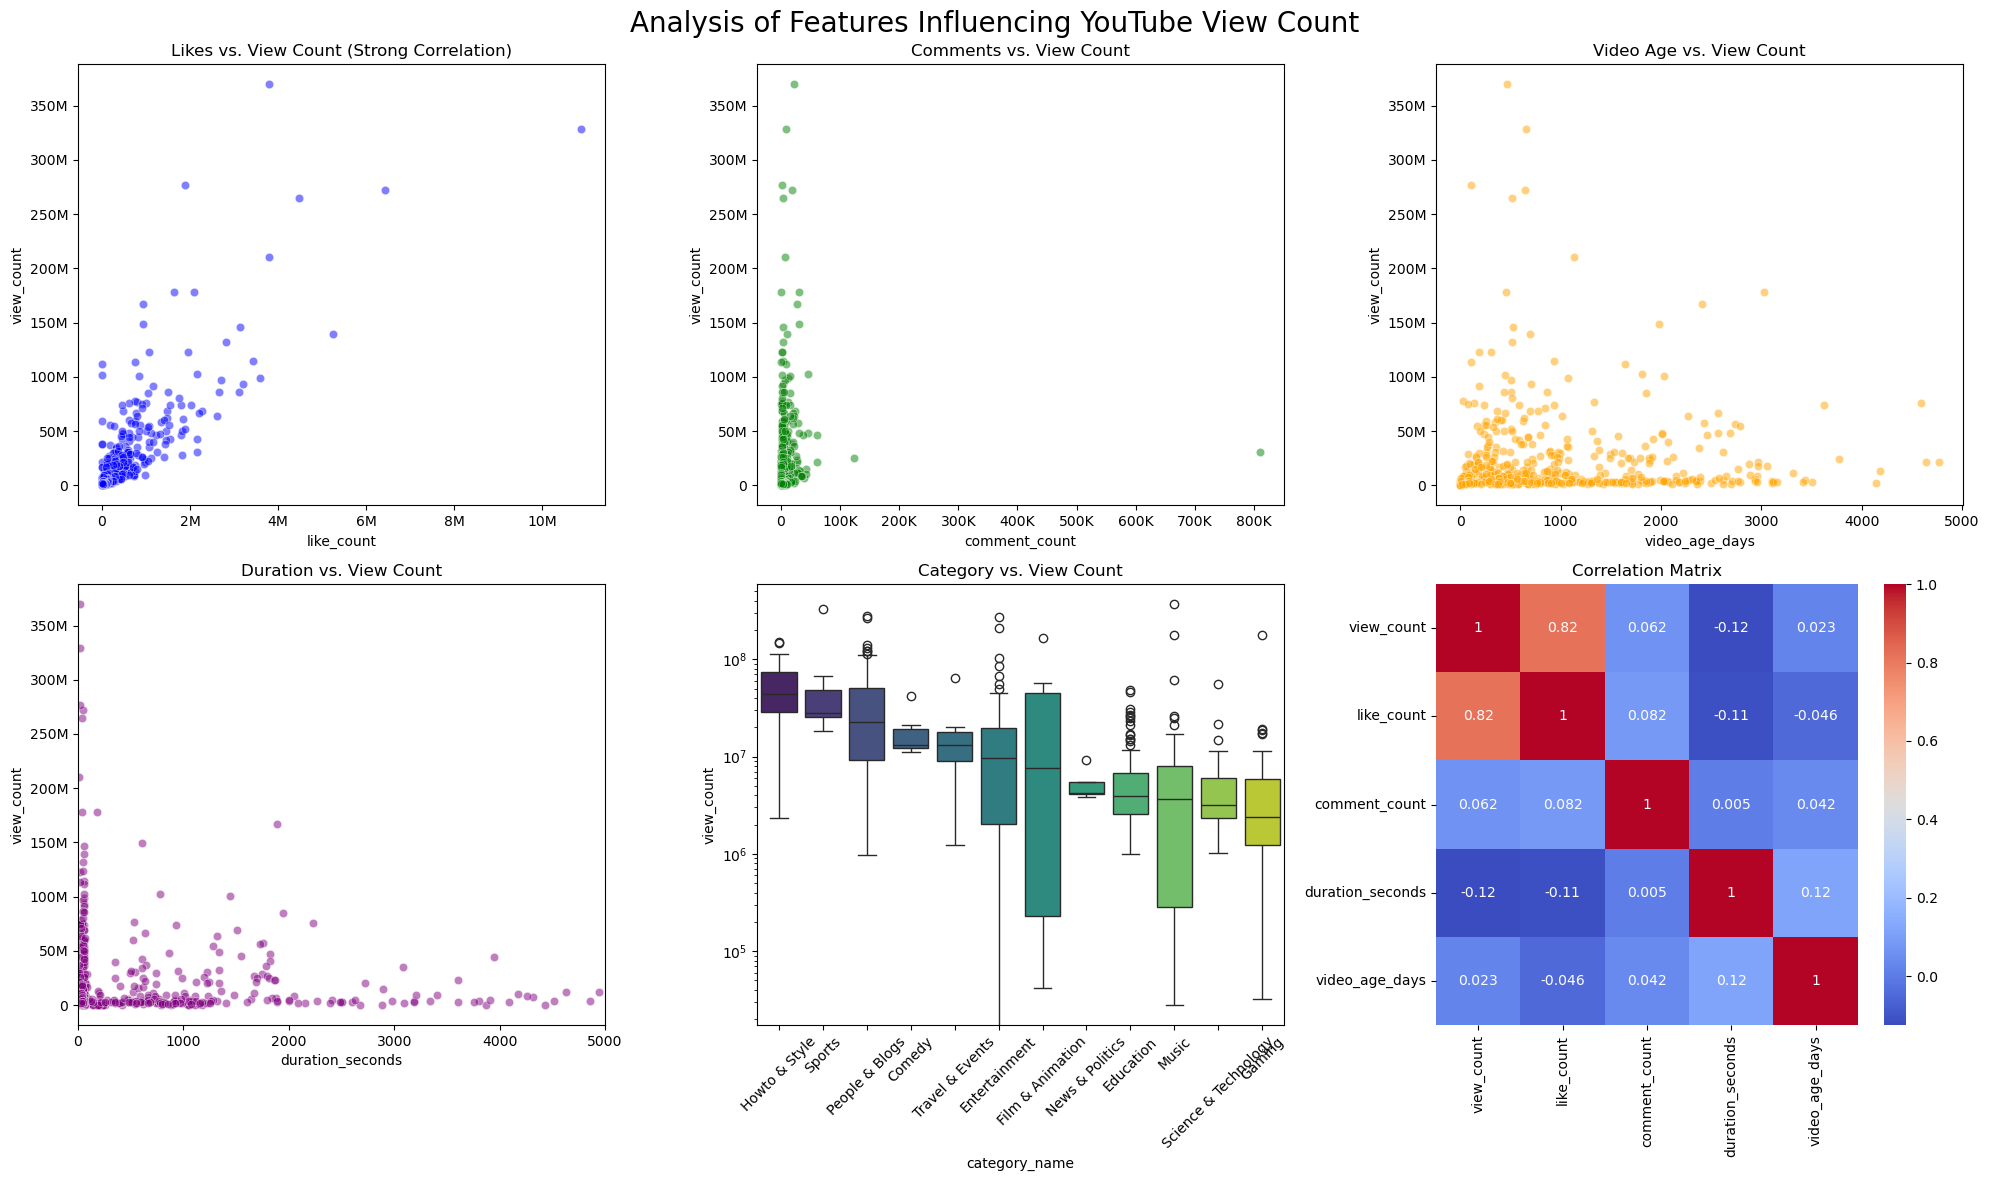

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Load the Data
df = pd.read_csv('youtube_recommendation_dataset -.csv')

# 2. Map Category IDs to Names
category_map = {
    1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals',
    17: 'Sports', 19: 'Travel & Events', 20: 'Gaming', 22: 'People & Blogs',
    23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style',
    27: 'Education', 28: 'Science & Technology', 29: 'Nonprofits & Activism'
}
df['category_name'] = df['category_id'].map(category_map)

# 3. Helper to format large numbers (10M, 500K)
def human_format(num, pos):
    if num >= 1e6: return f'{num*1e-6:.0f}M'
    elif num >= 1e3: return f'{num*1e-3:.0f}K'
    return f'{num:.0f}'
formatter = FuncFormatter(human_format)

# 4. Visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Analysis of Features Influencing YouTube View Count', fontsize=20)

# Plot 1: Likes vs View Count (Strongest Relationship)
sns.scatterplot(data=df, x='like_count', y='view_count', ax=axes[0, 0], alpha=0.5, color='blue')
axes[0, 0].set_title('Likes vs. View Count (Strong Correlation)')
axes[0, 0].xaxis.set_major_formatter(formatter)
axes[0, 0].yaxis.set_major_formatter(formatter)

# Plot 2: Comments vs View Count (Weak Relationship)
sns.scatterplot(data=df, x='comment_count', y='view_count', ax=axes[0, 1], alpha=0.5, color='green')
axes[0, 1].set_title('Comments vs. View Count')
axes[0, 1].xaxis.set_major_formatter(formatter)
axes[0, 1].yaxis.set_major_formatter(formatter)

# Plot 3: Video Age vs View Count (No Relationship)
sns.scatterplot(data=df, x='video_age_days', y='view_count', ax=axes[0, 2], alpha=0.5, color='orange')
axes[0, 2].set_title('Video Age vs. View Count')
axes[0, 2].yaxis.set_major_formatter(formatter)

# Plot 4: Duration vs View Count
sns.scatterplot(data=df, x='duration_seconds', y='view_count', ax=axes[1, 0], alpha=0.5, color='purple')
axes[1, 0].set_title('Duration vs. View Count')
axes[1, 0].set_xlim(0, 5000) # Focus on videos under ~80 mins
axes[1, 0].yaxis.set_major_formatter(formatter)

# Plot 5: Category vs View Count
order = df.groupby('category_name')['view_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category_name', y='view_count', order=order, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Category vs. View Count')
axes[1, 1].set_yscale('log') # Log scale for better visibility
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 6: Correlation Matrix
numeric_cols = ['view_count', 'like_count', 'comment_count', 'duration_seconds', 'video_age_days']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

#The Target Feature: 
Views


#Features
Category Name - The category the video belongs to in youtube
Duration - how long the video last
comments count - how many comments on the video 
view counts - how many views did the video get
like counts - how many likes a video got
video age - how long ago was the video posted on youtube

From the corrolation matrix we can derive that the amount of time a video is online does not mean that the like amount will be any bigger. 
Entertainment happens to be the largest sector of youtube content. while Howto-style videos tend to get the most as a mean. 
The duration of a video does not seem to change how much view a video gets. it seems like that videos that are short and have a high reshareability will get more view from how quick the video is.
videos seem to stay under the 50 million mark while a few outliars exist that show that these videos online can spread like wild fire.
Not alot of people seem to comment on videos even when the videos have millions of views. 

And finally there seems to be a miniture upwards trend to view to like ratio. the move views the higher the likes. 
The corralation could be that people who like the video tend to share the videos or is reccommended by youtube because other people have deemed it as quality youtube content.

The big picture narrative of all this data seems to be that a quality short form video with high reshareability with the main theme of Howto/ style videos will yield the highest amount of viewership on the platform. I find that this lines up with alot of my views on the platform especially with youtube shorts/ short form content. People like Corridor Digital had a company contest to see who can make the most satisfying renders that loop for Youtuber short form content. And by the end of the video they had millions of views on these shorts. They were high quality satifying, looping, highly reshareable videos with highly stylized content. Quality, Reshareability, and time consuption are the most highest driving factors. after all the way videos are going, with the near death of live streaming platforms and the attention span of todays modern generations. People look at short form content and think "oh i have time for this its only 5 seconds long" but then it starts to rack up video after video until you've watched 50 five seconds videos. and never realized how much time you had used to consume content. Not only that but changing videos with a simple swipe feeds into the alloance of the user who wants to watch the videos. its easy and simple, and I gotta stay entertained for the next few moments of being. The internet is a strange and wonderful place with many pitfalls.  Like what Bo BUrnham said in his welcome to the internet song
"A little bit of everything
All of the time
Apathy's a tragedy
And boredom is a crime
Anything and everything
All of the time
"